<a href="https://colab.research.google.com/github/aslikorkmaz48/NLP_14_Gunluk_Kamp/blob/main/%20G%C3%BCn05_Kelime_Vektorleri_ve_Gorsellestirme_tSNE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Gerekli kütüphaneler
!pip install gensim matplotlib scikit-learn --quiet
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 2. Mini Eğitim Verisi (Bilgisayarın dünyayı tanıması için)

sentences = [
    ["kral", "saray", "taht", "erkek", "güç"],
    ["kraliçe", "saray", "taht", "kadın", "zarif"],
    ["elma", "meyve", "vitamin", "kırmızı", "tatlı"],
    ["armut", "meyve", "vitamin", "sarı", "tatlı"],
    ["bilgisayar", "yazılım", "kod", "teknoloji", "ekran"],
    ["telefon", "mobil", "uygulama", "teknoloji", "ekran"]
]

# 3. Modeli Eğitme
# vector_size=100 -> Her kelimeye 100 farklı özellik ver (anlam derinliği)
model = Word2Vec(sentences, vector_size=100, window=2, min_count=1, sg=1)

# 4. MATEMATİKSEL KANIT: Kelime Benzerliği
print("🔍 'Kral' ile en benzer kelimeler:")
print(model.wv.most_similar("kral", topn=3))

print("\n🔍 'Meyve' ile en benzer kelimeler:")
print(model.wv.most_similar("meyve", topn=2))

# 5. EFSANE TEST: Kelime Matematiği (Kral - Erkek + Kadın = ?)
# Not: Veri setimiz küçük olduğu için tam sonuç vermeyebilir
result = model.wv.most_similar(positive=['kraliçe', 'erkek'], negative=['kadın'])
print(f"\n✨ Matematiksel Tahmin (Kraliçe - Kadın + Erkek): {result[0][0]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.4 MB/s eta 0:00:00
🔍 'Kral' ile en benzer kelimeler:
[('kırmızı', 0.19613029062747955), ('teknoloji', 0.18855656683444977), ('kod', 0.09932280331850052)]

🔍 'Meyve' ile en benzer kelimeler:
[('sarı', 0.2528878152370453), ('tatlı', 0.17018824815750122)]

✨ Matematiksel Tahmin (Kraliçe - Kadın + Erkek): saray


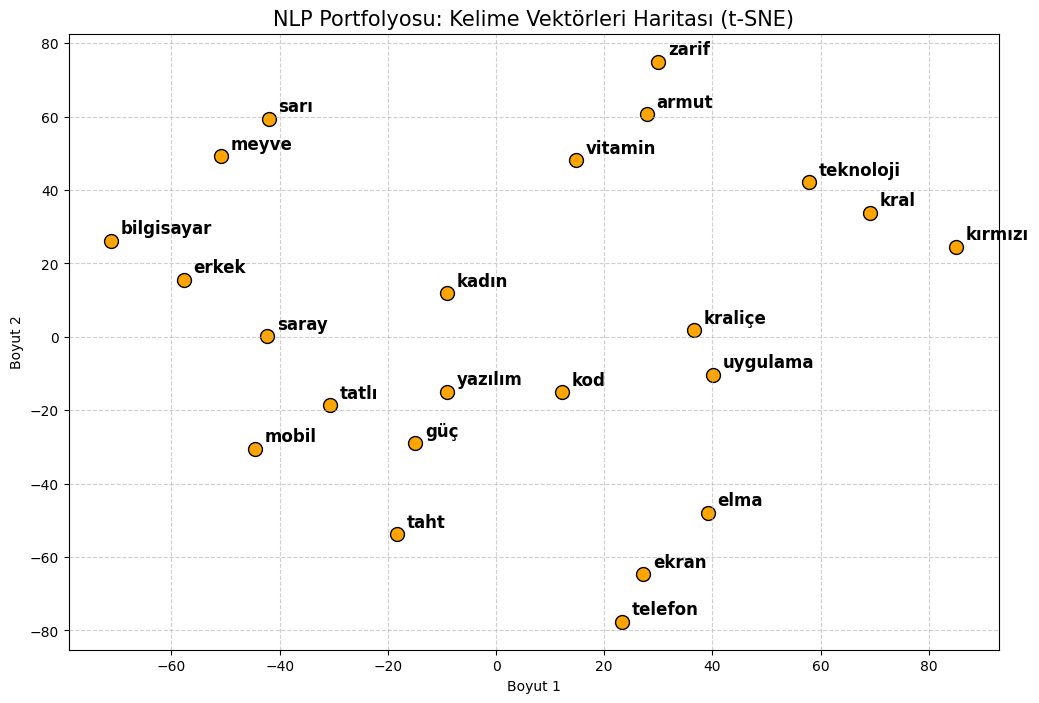

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Kelimeleri ve vektörlerini alalım
words = list(model.wv.index_to_key)
vectors = np.array([model.wv[w] for w in words])

# 2. t-SNE ile 100 boyutu 2 boyuta düşürelim
# perplexity değerini veri boyutuna göre ayarlıyoruz
tsne = TSNE(n_components=2, random_state=42, perplexity=min(len(words)-1, 5))
vectors_2d = tsne.fit_transform(vectors)

# 3. Görselleştirme
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='orange', edgecolors='k', s=100)

# Her noktanın üzerine kelimesini yazalım
for i, word in enumerate(words):
    plt.annotate(word,
                 xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                 xytext=(7, 5),
                 textcoords='offset points',
                 fontsize=12,
                 fontweight='bold')

plt.title("NLP Portfolyosu: Kelime Vektörleri Haritası (t-SNE)", fontsize=15)
plt.xlabel("Boyut 1")
plt.ylabel("Boyut 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()